In [22]:
import pandas as pd 
import shapely 
import geopandas as gpd
import scipy
import matplotlib.pyplot as plt

# Data Loading

In [2]:
health = pd.read_csv('/Users/medhasubramaniyan/Desktop/GitHub_Repos/hoop-deserts-atl/data/raw/PLACES__Local_Data_for_Better_Health,_Census_Tract_Data,_2025_release_20260811.csv')
health #already filtered to dekalb and fulton 

,Year,StateAbbr,StateDesc,CountyName,CountyFIPS,LocationName,DataSource,Category,Measure,Data_Value_Unit,...,Low_Confidence_Limit,High_Confidence_Limit,TotalPopulation,TotalPop18plus,Geolocation,LocationID,CategoryID,MeasureId,DataValueTypeID,Short_Question_Text
0,2022,GA,Georgia,DeKalb,13089,13089022403,BRFSS,Prevention,Colorectal cancer screening among adults aged ...,%,...,70.9,78.1,"4,119","3,202",POINT (-84.3212938 33.7761539),13089022403,PREVENT,COLON_SCREEN,CrdPrv,Colorectal Cancer Screening
1,2023,GA,Georgia,DeKalb,13089,13089022203,BRFSS,Health-Related Social Needs,Received food stamps in the past 12 months amo...,%,...,6.6,10.2,"2,435","2,114",POINT (-84.2743533 33.7864692),13089022203,SOCLNEED,FOODSTAMP,CrdPrv,Food Stamps
2,2023,GA,Georgia,DeKalb,13089,13089023424,BRFSS,Health Outcomes,Diagnosed diabetes among adults,%,...,14.8,18.8,"5,366","4,111",POINT (-84.2876394 33.670735),13089023424,HLTHOUT,DIABETES,CrdPrv,Diabetes
3,2023,GA,Georgia,DeKalb,13089,13089023413,BRFSS,Health Risk Behaviors,Current cigarette smoking among adults,%,...,9.7,14.1,"3,482","2,889",POINT (-84.2382775 33.6919664),13089023413,RISKBEH,CSMOKING,CrdPrv,Current Cigarette Smoking
4,2023,GA,Georgia,DeKalb,13089,13089021223,BRFSS,Health Outcomes,Chronic obstructive pulmonary disease among ad...,%,...,2.0,3.1,"2,405","1,691",POINT (-84.3337899 33.9403169),13089021223,HLTHOUT,COPD,CrdPrv,COPD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21115,2023,GA,Georgia,Fulton,13121,13121011306,BRFSS,Disability,Any disability among adults,%,...,30.3,38.3,"3,371","2,481",POINT (-84.50339 33.6389921),13121011306,DISABLT,DISABILITY,CrdPrv,Any Disability
21116,2023,GA,Georgia,Fulton,13121,13121011627,BRFSS,Health Outcomes,Diagnosed diabetes among adults,%,...,9.1,12.0,"4,418","3,379",POINT (-84.1812816 34.0259786),13121011627,HLTHOUT,DIABETES,CrdPrv,Diabetes
21117,2023,GA,Georgia,Fulton,13121,13121011654,BRFSS,Health Outcomes,Arthritis among adults,%,...,17.4,21.8,"2,794","2,151",POINT (-84.3143145 34.075416),13121011654,HLTHOUT,ARTHRITIS,CrdPrv,Arthritis
21118,2023,GA,Georgia,Fulton,13121,13121010529,BRFSS,Disability,Vision disability among adults,%,...,5.0,6.7,"6,290","4,729",POINT (-84.5088194 33.6027377),13121010529,DISABLT,VISION,CrdPrv,Vision Disability


In [3]:
courts = gpd.read_file('/Users/medhasubramaniyan/Desktop/GitHub_Repos/hoop-deserts-atl/data/raw/export (1).geojson')
courts #courts in Atlanta, must verify they fit within fulton and dekalb

,id,@id,access,addr:city,addr:housenumber,addr:postcode,addr:state,addr:street,attribution,barrier,...,name,nysgissam:nysaddresspointid,operator,quantity,smoking,source,sport,surface,wheelchair,geometry
0,way/28507812,way/28507812,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,basketball,paved,None,"POLYGON ((-84.29748 33.75718, -84.29748 33.756..."
1,way/40877278,way/40877278,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,basketball,concrete,None,"POLYGON ((-84.32096 33.75506, -84.32112 33.755..."
2,way/40877545,way/40877545,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,basketball,None,None,"POLYGON ((-84.3374 33.75196, -84.3374 33.75173..."
3,way/40941425,way/40941425,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,basketball,None,None,"POLYGON ((-84.3577 33.70411, -84.35754 33.7041..."
4,way/40941426,way/40941426,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,basketball,None,None,"POLYGON ((-84.35754 33.70423, -84.35754 33.704..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
345,node/12215093688,node/12215093688,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,basketball,None,None,POINT (-84.57022 33.6441)
346,node/12215093707,node/12215093707,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,basketball,None,None,POINT (-84.56166 33.71072)
347,node/12215093733,node/12215093733,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,basketball,None,None,POINT (-84.53101 33.72892)
348,node/13666936574,node/13666936574,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,basketball,None,None,POINT (-84.39037 34.01343)


In [4]:
census = pd.read_json('/Users/medhasubramaniyan/Desktop/GitHub_Repos/hoop-deserts-atl/data/raw/censusgov.json')

census.columns = census.iloc[0] #assign first row of dataframe to columns
census = census[1:].reset_index(drop=True) #slice out the existing (now columns) row, keep the rest, and reset the index from 0 '

census.rename(columns={
    "B19013_001E": "median_household_income",
    "B17001_001E": "poverty_universe",
    "B17001_002E": "population_in_poverty",
    "B02001_001E": "race_universe",
    "B02001_002E": "pop_white_alone",
    "B02001_003E": "pop_black_alone",
    "B03003_003E": "pop_hispanic_or_latino",
    "B01003_001E": "total_population",
}, inplace=True) #rename the old variable codes to more distinguishable names 
census #already filtered to dekalb and fulton 

,NAME,median_household_income,population_in_poverty,poverty_universe,race_universe,pop_white_alone,pop_black_alone,pop_hispanic_or_latino,total_population,state,county,tract
0,Census Tract 201; DeKalb County; Georgia,181250,144,2128,2128,1948,26,193,2128,13,089,020100
1,Census Tract 202; DeKalb County; Georgia,93068,201,2068,2068,1556,76,70,2068,13,089,020200
2,Census Tract 203; DeKalb County; Georgia,175885,388,4548,4548,3357,314,339,4548,13,089,020300
3,Census Tract 204; DeKalb County; Georgia,188438,79,2714,2714,2244,95,119,2714,13,089,020400
4,Census Tract 205; DeKalb County; Georgia,99961,236,3546,3546,1901,1082,240,3546,13,089,020500
...,...,...,...,...,...,...,...,...,...,...,...,...
525,Census Tract 119.01; Fulton County; Georgia,55000,400,1477,1857,587,1088,184,1857,13,121,011901
526,Census Tract 119.02; Fulton County; Georgia,-666666666,382,1275,1275,428,602,93,1275,13,121,011902
527,Census Tract 120; Fulton County; Georgia,-666666666,2111,3587,3615,541,2741,145,3615,13,121,012000
528,Census Tract 123; Fulton County; Georgia,49855,227,2141,2175,669,1106,72,2175,13,121,012300


In [5]:
tracts = gpd.read_file('/Users/medhasubramaniyan/Desktop/GitHub_Repos/hoop-deserts-atl/data/raw/tl_2025_13_tract/tl_2025_13_tract.shp')

tracts = tracts[tracts['COUNTYFP'].isin(['121', '089'])]

tracts['COUNTYFP'].unique()
tracts.reset_index(drop=True,inplace=True)
tracts
# COUNTYFP for DeKalb County is 089 and for Fulton County is 121.

,STATEFP,COUNTYFP,TRACTCE,GEOID,GEOIDFQ,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
0,13,121,011417,13121011417,1400000US13121011417,114.17,Census Tract 114.17,G5020,S,7528526,92041,+34.0564788,-084.3693603,"POLYGON ((-84.39568 34.06267, -84.39566 34.062..."
1,13,121,011416,13121011416,1400000US13121011416,114.16,Census Tract 114.16,G5020,S,6618016,38422,+34.0649975,-084.3455864,"POLYGON ((-84.36105 34.07631, -84.36058 34.076..."
2,13,121,011421,13121011421,1400000US13121011421,114.21,Census Tract 114.21,G5020,S,3898568,38427,+34.0405266,-084.3328370,"POLYGON ((-84.34344 34.03709, -84.34324 34.038..."
3,13,121,006000,13121006000,1400000US13121006000,60,Census Tract 60,G5020,S,1566210,0,+33.7379429,-084.4390350,"POLYGON ((-84.44735 33.73454, -84.4472 33.7353..."
4,13,121,003600,13121003600,1400000US13121003600,36,Census Tract 36,G5020,S,393883,0,+33.7518731,-084.4029233,"POLYGON ((-84.40656 33.75127, -84.40656 33.751..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
525,13,089,021409,13089021409,1400000US13089021409,214.09,Census Tract 214.09,G5020,S,1041466,0,+33.8610663,-084.2957708,"POLYGON ((-84.30351 33.85028, -84.30295 33.850..."
526,13,089,023111,13089023111,1400000US13089023111,231.11,Census Tract 231.11,G5020,S,2337613,14379,+33.7574297,-084.2269034,"POLYGON ((-84.23328 33.77092, -84.23313 33.770..."
527,13,089,022010,13089022010,1400000US13089022010,220.10,Census Tract 220.10,G5020,S,1244723,19837,+33.8131970,-084.2297640,"POLYGON ((-84.23965 33.80943, -84.23908 33.810..."
528,13,089,023113,13089023113,1400000US13089023113,231.13,Census Tract 231.13,G5020,S,2039843,8918,+33.7771900,-084.2532758,"POLYGON ((-84.26725 33.77686, -84.26689 33.777..."


# Data Inspection

In [6]:
census.info()
census.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 530 entries, 0 to 529
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   NAME                     530 non-null    object
 1   median_household_income  530 non-null    object
 2   population_in_poverty    530 non-null    object
 3   poverty_universe         530 non-null    object
 4   race_universe            530 non-null    object
 5   pop_white_alone          530 non-null    object
 6   pop_black_alone          530 non-null    object
 7   pop_hispanic_or_latino   530 non-null    object
 8   total_population         530 non-null    object
 9   state                    530 non-null    object
 10  county                   530 non-null    object
 11  tract                    530 non-null    object
dtypes: object(12)
memory usage: 49.8+ KB


,NAME,median_household_income,population_in_poverty,poverty_universe,race_universe,pop_white_alone,pop_black_alone,pop_hispanic_or_latino,total_population,state,county,tract
count,530,530,530,530,530,530,530,530,530,530,530,530
unique,530,506,393,506,501,467,485,336,501,1,2,529
top,Census Tract 201; DeKalb County; Georgia,-666666666,0,3115,2175,0,0,0,2175,13,121,980000
freq,1,14,10,3,3,16,5,32,3,530,327,2


In [7]:
census.isnull().sum() #theres no nulls, however -6666666 is used often (sentinel null )

0
NAME                       0
median_household_income    0
population_in_poverty      0
poverty_universe           0
race_universe              0
pop_white_alone            0
pop_black_alone            0
pop_hispanic_or_latino     0
total_population           0
state                      0
county                     0
tract                      0
dtype: int64

In [8]:
courts.info()
courts.describe()
courts.shape
courts.columns


<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 29 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   id                           350 non-null    object  
 1   @id                          350 non-null    object  
 2   access                       68 non-null     object  
 3   addr:city                    2 non-null      object  
 4   addr:housenumber             2 non-null      object  
 5   addr:postcode                2 non-null      object  
 6   addr:state                   2 non-null      object  
 7   addr:street                  2 non-null      object  
 8   attribution                  1 non-null      object  
 9   barrier                      1 non-null      object  
 10  capacity                     1 non-null      object  
 11  covered                      3 non-null      object  
 12  fee                          4 non-null      object  
 1

Index(['id', '@id', 'access', 'addr:city', 'addr:housenumber', 'addr:postcode',
       'addr:state', 'addr:street', 'attribution', 'barrier', 'capacity',
       'covered', 'fee', 'hoops', 'indoor', 'layer', 'leisure', 'lit',
       'location', 'name', 'nysgissam:nysaddresspointid', 'operator',
       'quantity', 'smoking', 'source', 'sport', 'surface', 'wheelchair',
       'geometry'],
      dtype='object')

In [9]:
courts.isnull().sum() # lots of nulls (None) abscence of values 
courts[courts['access'].isnull()]

,id,@id,access,addr:city,addr:housenumber,addr:postcode,addr:state,addr:street,attribution,barrier,...,name,nysgissam:nysaddresspointid,operator,quantity,smoking,source,sport,surface,wheelchair,geometry
0,way/28507812,way/28507812,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,basketball,paved,None,"POLYGON ((-84.29748 33.75718, -84.29748 33.756..."
1,way/40877278,way/40877278,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,basketball,concrete,None,"POLYGON ((-84.32096 33.75506, -84.32112 33.755..."
2,way/40877545,way/40877545,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,basketball,None,None,"POLYGON ((-84.3374 33.75196, -84.3374 33.75173..."
3,way/40941425,way/40941425,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,basketball,None,None,"POLYGON ((-84.3577 33.70411, -84.35754 33.7041..."
4,way/40941426,way/40941426,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,basketball,None,None,"POLYGON ((-84.35754 33.70423, -84.35754 33.704..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
345,node/12215093688,node/12215093688,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,basketball,None,None,POINT (-84.57022 33.6441)
346,node/12215093707,node/12215093707,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,basketball,None,None,POINT (-84.56166 33.71072)
347,node/12215093733,node/12215093733,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,basketball,None,None,POINT (-84.53101 33.72892)
348,node/13666936574,node/13666936574,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,basketball,None,None,POINT (-84.39037 34.01343)


In [10]:
tracts.info()
tracts.describe()
tracts.shape
tracts.columns

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 530 entries, 0 to 529
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   STATEFP   530 non-null    object  
 1   COUNTYFP  530 non-null    object  
 2   TRACTCE   530 non-null    object  
 3   GEOID     530 non-null    object  
 4   GEOIDFQ   530 non-null    object  
 5   NAME      530 non-null    object  
 6   NAMELSAD  530 non-null    object  
 7   MTFCC     530 non-null    object  
 8   FUNCSTAT  530 non-null    object  
 9   ALAND     530 non-null    int64   
 10  AWATER    530 non-null    int64   
 11  INTPTLAT  530 non-null    object  
 12  INTPTLON  530 non-null    object  
 13  geometry  530 non-null    geometry
dtypes: geometry(1), int64(2), object(11)
memory usage: 58.1+ KB


Index(['STATEFP', 'COUNTYFP', 'TRACTCE', 'GEOID', 'GEOIDFQ', 'NAME',
       'NAMELSAD', 'MTFCC', 'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT',
       'INTPTLON', 'geometry'],
      dtype='object')

In [11]:
tracts.isnull().sum() # no nuls 
tracts
# STATEFP, COUNTYFP, TRACTCE, GEOID, GEOIDFQ

,STATEFP,COUNTYFP,TRACTCE,GEOID,GEOIDFQ,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
0,13,121,011417,13121011417,1400000US13121011417,114.17,Census Tract 114.17,G5020,S,7528526,92041,+34.0564788,-084.3693603,"POLYGON ((-84.39568 34.06267, -84.39566 34.062..."
1,13,121,011416,13121011416,1400000US13121011416,114.16,Census Tract 114.16,G5020,S,6618016,38422,+34.0649975,-084.3455864,"POLYGON ((-84.36105 34.07631, -84.36058 34.076..."
2,13,121,011421,13121011421,1400000US13121011421,114.21,Census Tract 114.21,G5020,S,3898568,38427,+34.0405266,-084.3328370,"POLYGON ((-84.34344 34.03709, -84.34324 34.038..."
3,13,121,006000,13121006000,1400000US13121006000,60,Census Tract 60,G5020,S,1566210,0,+33.7379429,-084.4390350,"POLYGON ((-84.44735 33.73454, -84.4472 33.7353..."
4,13,121,003600,13121003600,1400000US13121003600,36,Census Tract 36,G5020,S,393883,0,+33.7518731,-084.4029233,"POLYGON ((-84.40656 33.75127, -84.40656 33.751..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
525,13,089,021409,13089021409,1400000US13089021409,214.09,Census Tract 214.09,G5020,S,1041466,0,+33.8610663,-084.2957708,"POLYGON ((-84.30351 33.85028, -84.30295 33.850..."
526,13,089,023111,13089023111,1400000US13089023111,231.11,Census Tract 231.11,G5020,S,2337613,14379,+33.7574297,-084.2269034,"POLYGON ((-84.23328 33.77092, -84.23313 33.770..."
527,13,089,022010,13089022010,1400000US13089022010,220.10,Census Tract 220.10,G5020,S,1244723,19837,+33.8131970,-084.2297640,"POLYGON ((-84.23965 33.80943, -84.23908 33.810..."
528,13,089,023113,13089023113,1400000US13089023113,231.13,Census Tract 231.13,G5020,S,2039843,8918,+33.7771900,-084.2532758,"POLYGON ((-84.26725 33.77686, -84.26689 33.777..."


In [12]:
health.info()
health.describe()
health.shape
health.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21120 entries, 0 to 21119
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Year                        21120 non-null  int64  
 1   StateAbbr                   21120 non-null  object 
 2   StateDesc                   21120 non-null  object 
 3   CountyName                  21120 non-null  object 
 4   CountyFIPS                  21120 non-null  int64  
 5   LocationName                21120 non-null  int64  
 6   DataSource                  21120 non-null  object 
 7   Category                    21120 non-null  object 
 8   Measure                     21120 non-null  object 
 9   Data_Value_Unit             21120 non-null  object 
 10  Data_Value_Type             21120 non-null  object 
 11  Data_Value                  21120 non-null  float64
 12  Data_Value_Footnote_Symbol  0 non-null      float64
 13  Data_Value_Footnote         0 n

Index(['Year', 'StateAbbr', 'StateDesc', 'CountyName', 'CountyFIPS',
       'LocationName', 'DataSource', 'Category', 'Measure', 'Data_Value_Unit',
       'Data_Value_Type', 'Data_Value', 'Data_Value_Footnote_Symbol',
       'Data_Value_Footnote', 'Low_Confidence_Limit', 'High_Confidence_Limit',
       'TotalPopulation', 'TotalPop18plus', 'Geolocation', 'LocationID',
       'CategoryID', 'MeasureId', 'DataValueTypeID', 'Short_Question_Text'],
      dtype='object')

# Data Cleaning

## Dtype cleanup/correction + Null Handling

In [13]:
# Cast the Census internal point to float
tracts['INTPTLAT'] = tracts['INTPTLAT'].astype(float)   # '+34.2599764'  -> 34.2599764
tracts['INTPTLON'] = tracts['INTPTLON'].astype(float)   # '-084.2447452' -> -84.2447452

# Drop columns that carry no information for this analysis.
tracts = tracts.drop(columns=['GEOIDFQ', 'MTFCC', 'FUNCSTAT'])

tracts.dtypes



STATEFP       object
COUNTYFP      object
TRACTCE       object
GEOID         object
NAME          object
NAMELSAD      object
ALAND          int64
AWATER         int64
INTPTLAT     float64
INTPTLON     float64
geometry    geometry
dtype: object

In [14]:
# Identifiers stay strings — leading zeros are meaningful ('089', not 89).
id_cols = ['state', 'county', 'tract']
census[id_cols] = census[id_cols].astype('string')
census['NAME'] = census['NAME'].astype('string')
# Using .astype(str) or .astype('str') converts missing values into the literal text string 'nan', 
# while .astype('string') preserves them as true missing values (<NA>)


# Everything else is a count or dollar amount
numerics = []
for col in census.columns:
    if col not in id_cols + ['NAME', 'GEOID']:
        numerics.append(col)
#if the  column is not in ['state', 'county', 'tract', 'NAME', 'GEOID'] add it to the numeric column

census[numerics] = census[numerics].apply(pd.to_numeric, errors='coerce')


# The Census API encodes "no estimate available" as -666666666, not null.
# pd.to_numeric parses those into valid negative numbers, so mask them
census[numerics] = census[numerics].mask(census[numerics] < 0)
#.mask() says "Wherever the condition is True, replace the value with NaN." 

census['GEOID'] = census['state'] + census['county'] + census['tract']

assert census['GEOID'].str.len().eq(11).all(), "GEOID must be 11 chars"
#  statement is used to test conditions in your code. If the condition evaluates to True, the code continues running. 
# If it evaluates to False, Python raises an AssertionError and halts execution. 
# .eq() means equals, so if str.len() equals 11 
#.all() returns True if all values we are checking result to true 
census[numerics].isna().sum()


0
median_household_income    14
population_in_poverty       0
poverty_universe            0
race_universe               0
pop_white_alone             0
pop_black_alone             0
pop_hispanic_or_latino      0
total_population            0
dtype: int64

In [15]:
# LocationID arrives as int64 (13089022403) but tracts.GEOID is a string.
# Merging across that type mismatch returns ZERO rows and raises no error.
health['GEOID'] = health['LocationID'].astype(str).str.zfill(11)
health['CountyFIPS'] = health['CountyFIPS'].astype(str).str.zfill(5)

# Thousands separators made this object; strip them before casting.
health['TotalPopulation'] = pd.to_numeric(
    health['TotalPopulation'].astype(str).str.replace(',', '', regex=False),
    errors='coerce',
)
health['TotalPop18plus'] = pd.to_numeric(
    health['TotalPop18plus'].astype(str).str.replace(',', '', regex=False),
    errors='coerce',
)
#regex=False: Tells Pandas to treat the comma as text,

#both are 100% null
health.drop(columns=['Data_Value_Footnote_Symbol', 'Data_Value_Footnote'], inplace=True)

# Low-cardinality repeated strings -> category (40 measures across 21k rows).
for col in ['StateAbbr', 'CountyName', 'MeasureId', 'Category', 'Measure', 'DataValueTypeID']:
    health[col] = health[col].astype('category')

assert health['GEOID'].str.len().eq(11).all()
health[['GEOID', 'CountyFIPS', 'TotalPopulation', 'MeasureId', 'TotalPop18plus']].dtypes
health.isna().sum()


Year                     0
StateAbbr                0
StateDesc                0
CountyName               0
CountyFIPS               0
LocationName             0
DataSource               0
Category                 0
Measure                  0
Data_Value_Unit          0
Data_Value_Type          0
Data_Value               0
Low_Confidence_Limit     0
High_Confidence_Limit    0
TotalPopulation          0
TotalPop18plus           0
Geolocation              0
LocationID               0
CategoryID               0
MeasureId                0
DataValueTypeID          0
Short_Question_Text      0
GEOID                    0
dtype: int64

In [16]:

# 'hoops' is a count stored as an OSM string tag; 'layer' is a signed int.
courts['hoops'] = pd.to_numeric(courts['hoops'], errors='coerce').astype('Int64')


if 'layer' in courts.columns:
    courts['layer'] = pd.to_numeric(courts['layer'], errors='coerce').astype('Int64')
#if there is a column called layer in the df do this conversion 


# Every other OSM tag is free-text and stays object. They are sparsely populated:
courts[['access', 'hoops', 'surface', 'lit', 'name','layer']].notna().sum()


access      68
hoops      127
surface     37
lit         22
name         5
layer        2
dtype: int64

## 

## Handling Geographic Data
tracts —  Each tract is a shape covering an area of Fulton/DeKalb.

courts — court shapes.. Some are polygons (the painted court outline, from OSM way/), some are single points (node/).

In [17]:
#both came from different data sources, we need to make sure they are in the same format and align
print("courts:", courts.crs)   # EPSG:4326 (WGS84, OSM export)
print("tracts:", tracts.crs)   # EPSG:4269 (NAD83, TIGER shapefile)

courts = courts.to_crs(tracts.crs) #returns a new gdf with every coordinate mathematically re-projected into the target system
assert courts.crs == tracts.crs 




courts: EPSG:4326
tracts: EPSG:4269


In [18]:
#.centroid computes the geometric center of each shape and returns a Series of Points. 
# For a polygon that's the center of the painted rectangle for a Point, the centroid is that same point
print(courts.geom_type.value_counts())
courts['geometry'] = courts.geometry.centroid


Polygon    341
Point        9
Name: count, dtype: int64


/var/folders/cm/46nnvpl978b_vb10b1dp7rp80000gn/T/ipykernel_40794/3635448110.py:4: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  courts['geometry'] = courts.geometry.centroid


In [19]:
# spatial filter 
# The Overpass query matched county NAME, so it caught every Fulton/DeKalb in
# the US (Indianapolis, Missouri, Illinois, Ohio). No bounding-box filter is
# needed: the tract polygons ARE the study area, so how='inner' drops
# everything outside them by construction.
n_before = len(courts)
courts = gpd.sjoin(courts, tracts[['GEOID', 'NAMELSAD', 'geometry']],
                   how='inner', predicate='within')
courts = courts.drop(columns='index_right')
print(f'{n_before} nationwide -> {len(courts)} in Fulton + DeKalb')


350 nationwide -> 191 in Fulton + DeKalb


In [20]:
# validation
assert courts.GEOID.isin(tracts.GEOID).all()
assert not courts['id'].duplicated().any()
assert (courts.geom_type == 'Point').all()
assert courts.geometry.notna().all() and not courts.geometry.is_empty.any()

# Bounds sit inside the tract bounds — confirms the out-of-state courts are gone.
minx, miny, maxx, maxy = tracts.total_bounds
cminx, cminy, cmaxx, cmaxy = courts.total_bounds
assert minx <= cminx and cmaxx <= maxx and miny <= cminy and cmaxy <= maxy

print(f'{len(courts)} courts across {courts.GEOID.nunique()} of {len(tracts)} tracts')
print(f'{len(tracts) - courts.GEOID.nunique()} tracts have no court')
courts[['access', 'hoops', 'surface', 'lit', 'name']].notna().sum()


191 courts across 121 of 530 tracts
409 tracts have no court


access     33
hoops      47
surface    22
lit        18
name        4
dtype: int64

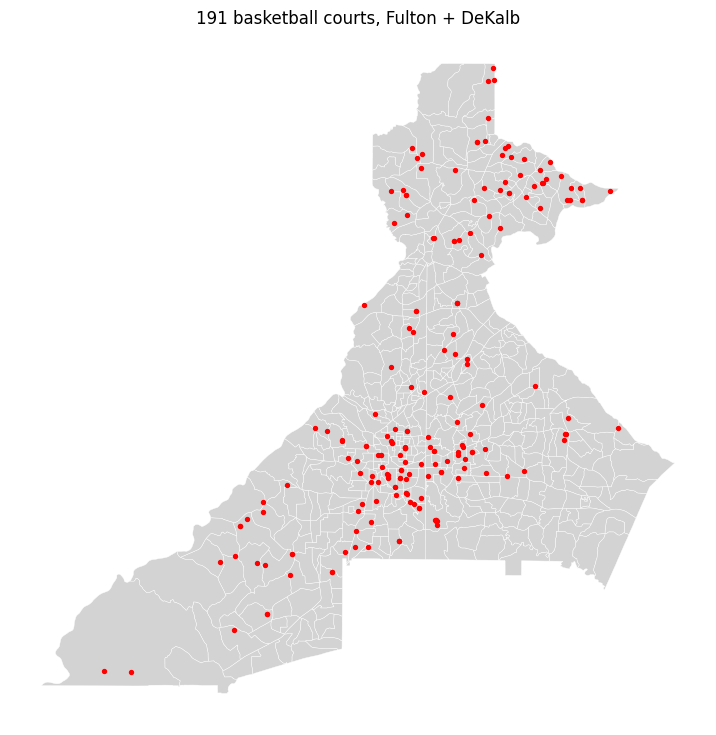

In [23]:
# viz
ax = tracts.plot(figsize=(9, 9), color='lightgrey', edgecolor='white', linewidth=0.3)
courts.plot(ax=ax, color='red', markersize=8)
ax.set_title(f'{len(courts)} basketball courts, Fulton + DeKalb')
ax.set_axis_off()
plt.show()


## Pivot health table

In [24]:
one = health[health['GEOID'] == '13089022403']
print(len(one))
one[['GEOID', 'Year', 'MeasureId', 'DataValueTypeID', 'Data_Value']].head(20)


40


,GEOID,Year,MeasureId,DataValueTypeID,Data_Value
0,13089022403,2022,COLON_SCREEN,CrdPrv,74.5
144,13089022403,2023,COGNITION,CrdPrv,7.7
296,13089022403,2023,INDEPLIVE,CrdPrv,4.2
420,13089022403,2023,MOBILITY,CrdPrv,7.3
903,13089022403,2023,SHUTUTILITY,CrdPrv,3.0
925,13089022403,2023,BPHIGH,CrdPrv,31.3
1155,13089022403,2023,EMOTIONSPT,CrdPrv,15.4
1575,13089022403,2023,LPA,CrdPrv,12.3
1591,13089022403,2023,HEARING,CrdPrv,5.4
2205,13089022403,2023,COPD,CrdPrv,3.6


In [ ]:
print(health.Year.unique())
print(health.DataValueTypeID.unique())
print(health['MeasureId'].nunique(), "distinct measures")

# The real question: how many rows per tract+measure?
health.groupby(['GEOID', 'MeasureId'], observed=True).size().value_counts()
#etting observed=True means the group operation will only include category combinations that actually exist in your dat


[2022 2023]
['CrdPrv']
Categories (1, object): ['CrdPrv']
40 distinct measures


1    21120
Name: count, dtype: int64

In [26]:
h = health[(health.Year == 2023) & (health.DataValueTypeID == 'CrdPrv')].copy()

# Now verify  every tract+measure pair should appear exactly once.
assert h.groupby(['GEOID', 'MeasureId'], observed=True).size().max() == 1


In [27]:
toy = h[h.GEOID == h.GEOID.iloc[0]][['GEOID', 'MeasureId', 'Data_Value']].head(3)
print("BEFORE (long):")
print(toy)

print("\nAFTER (wide):")
print(toy.pivot_table(index='GEOID', columns='MeasureId', values='Data_Value', observed=True))


BEFORE (long):
           GEOID  MeasureId  Data_Value
1    13089022203  FOODSTAMP         8.3
38   13089022203  INDEPLIVE         6.3
146  13089022203     BPHIGH        33.4

AFTER (wide):
MeasureId    BPHIGH  FOODSTAMP  INDEPLIVE
GEOID                                    
13089022203    33.4        8.3        6.3


In [28]:
health_wide = h.pivot_table(index='GEOID', columns='MeasureId',
                            values='Data_Value', observed=True)
health_wide.columns.name = None      # drop the leftover 'MeasureId' label
health_wide = health_wide.reset_index()

print(health_wide.shape)             # expect ~530 rows x (1 + n_measures)
assert health_wide.GEOID.is_unique

health_wide[['GEOID', 'OBESITY', 'LPA', 'MHLTH']].head(20)


(528, 36)


,GEOID,OBESITY,LPA,MHLTH
0,13089020100,24.1,13.2,13.1
1,13089020200,23.1,11.9,13.0
2,13089020300,26.0,13.7,13.7
3,13089020400,23.8,11.2,13.4
4,13089020500,27.6,15.7,15.4
5,13089020600,30.7,17.2,17.1
6,13089020700,28.2,15.6,16.0
7,13089020801,26.0,13.6,13.7
8,13089020802,30.3,18.5,15.6
9,13089020901,27.5,15.1,14.4


In [29]:
print(f"{len(tracts) - len(health_wide)} tracts missing from PLACES")


2 tracts missing from PLACES


# Joining Data

In [ ]:
# .size() counts rows per group. One row per court, so this is courts per tract.
# Only the 121 tracts WITH a court appear — the other 409 are absent, not zero.
court_count = courts.groupby('GEOID').size().rename('court_count')
#rename the series so we can save it as a variable and use it later

print(court_count.describe())
print(f"{court_count.sum()} courts across {len(court_count)} tracts")
court_count


count    121.000000
mean       1.578512
std        0.863636
min        1.000000
25%        1.000000
50%        1.000000
75%        2.000000
max        6.000000
Name: court_count, dtype: float64
191 courts across 121 tracts


GEOID
13089020300    2
13089020400    1
13089020500    1
13089020700    1
13089020802    1
              ..
13121011660    3
13121011661    1
13121011902    1
13121012000    3
13121012300    1
Name: court_count, Length: 121, dtype: int64

In [ ]:
print("tracts: ", len(tracts), "| unique GEOID:", tracts.GEOID.nunique())
print("census: ", len(census), "| unique GEOID:", census.GEOID.nunique())
print("health_wide:", len(health_wide), "| unique GEOID:", health_wide.GEOID.nunique())
#health wide is missing tracts 


tracts:  530 | unique GEOID: 530
census:  530 | unique GEOID: 530
health_wide: 528 | unique GEOID: 528


In [ ]:
# Left join off tracts at every step: tracts defines the study area, so a
# missing match must surface as NaN rather than as a silently dropped row.
analysis = (tracts
    .merge(census.drop(columns=['NAME', 'state', 'county', 'tract']),
           on='GEOID', how='left', validate='one_to_one')
    .merge(health_wide, on='GEOID', how='left', validate='one_to_one')
    .merge(court_count, on='GEOID', how='left', validate='one_to_one'))

assert len(analysis) == len(tracts), f"{len(analysis)} != {len(tracts)}"
print(type(analysis), analysis.shape)

#validate one to one makes pandas raise if either side has duplicate keys,
# result stays a GeoDataFrame because tracts is on the left so geometry is preserved. 
# Merging the other direction would give you a plain DataFrame


<class 'geopandas.geodataframe.GeoDataFrame'> (530, 55)


In [35]:
# Two different kinds of missing, handled differently:
# court_count NaN = no court fell in this tract = a real, true ZERO.
# census/health NaN = not measured or suppressed = genuinely UNKNOWN.
# Filling the first is correct. Filling the second would fabricate data.
analysis['court_count'] = analysis['court_count'].fillna(0).astype(int)

print(analysis[['median_household_income', 'total_population',
                'OBESITY', 'LPA', 'MHLTH', 'court_count']].isna().sum())
print(f"\n{(analysis.court_count == 0).sum()} tracts with zero courts")


median_household_income    14
total_population            0
OBESITY                     2
LPA                         2
MHLTH                       2
court_count                 0
dtype: int64

409 tracts with zero courts


In [37]:
cols = ['NAMELSAD', 'median_household_income', 'total_population', 'OBESITY', 'court_count']
print("HIGHEST INCOME:")
print(analysis.nlargest(5, 'median_household_income')[cols].to_string(index=False))
print("\nLOWEST INCOME:")
print(analysis.nsmallest(5, 'median_household_income')[cols].to_string(index=False))


HIGHEST INCOME:
           NAMELSAD  median_household_income  total_population  OBESITY  court_count
Census Tract 102.22                 250001.0              2790     20.0            0
Census Tract 115.07                 250001.0              4291     23.7            0
Census Tract 115.11                 250001.0              2372     21.4            0
Census Tract 101.07                 250001.0              1927     21.1            0
 Census Tract 91.05                 250001.0              1142     20.8            0

LOWEST INCOME:
          NAMELSAD  median_household_income  total_population  OBESITY  court_count
Census Tract 78.08                  14971.0              3877     48.7            0
   Census Tract 48                  16015.0              1241     44.0            2
Census Tract 28.02                  16620.0              2222     28.9            1
Census Tract 76.03                  19375.0              3152     43.0            2
Census Tract 55.03                  21

# Building Core Metrics

In [38]:
print(f"zero population:  {(analysis.total_population == 0).sum()} tracts")
print(f"under 100 people: {(analysis.total_population < 100).sum()} tracts")

tiny = analysis[analysis.total_population < 100]
print(tiny[['NAMELSAD', 'total_population', 'court_count', 'ALAND']].to_string(index=False))


zero population:  2 tracts
under 100 people: 2 tracts
         NAMELSAD  total_population  court_count   ALAND
Census Tract 9800                 0            0 2725013
Census Tract 9800                 0            0  644626


In [40]:
import numpy as np

# courts per 10,000 residents. Guard the denominator: a tract with 5 residents
# and 1 court yields 2000 per 10k, which is arithmetically correct and
# analytically garbage — it would dominate every mean and color scale.
POP_FLOOR = 100   # below this a per-capita rate is not meaningful

analysis['courts_per_10k'] = np.where(
    analysis.total_population >= POP_FLOOR,
    analysis.court_count / (analysis.total_population / 10_000),
    np.nan,
)

print(analysis.courts_per_10k.describe())
print(f"\n{analysis.courts_per_10k.isna().sum()} tracts excluded (pop < {POP_FLOOR})")
print(f"{(analysis.courts_per_10k == 0).sum()} tracts with density exactly 0")
print(f"{np.isinf(analysis.courts_per_10k).sum()} infinite values")   # must be 0


count    528.000000
mean       1.177791
std        2.982394
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max       34.090909
Name: courts_per_10k, dtype: float64

2 tracts excluded (pop < 100)
407 tracts with density exactly 0
0 infinite values


In [41]:
# ALAND is land area in square meters (TIGER). 2,589,988 m² = 1 sq mile.
analysis['area_sqmi'] = analysis.ALAND / 2_589_988
analysis['courts_per_sqmi'] = np.where(
    analysis.area_sqmi > 0,
    analysis.court_count / analysis.area_sqmi,
    np.nan,
)

analysis[['courts_per_10k', 'courts_per_sqmi']].describe()


,courts_per_10k,courts_per_sqmi
count,528.000000,530.000000
mean,1.177791,0.477652
std,2.982394,1.716614
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,0.000000,0.000000
max,34.090909,27.176282


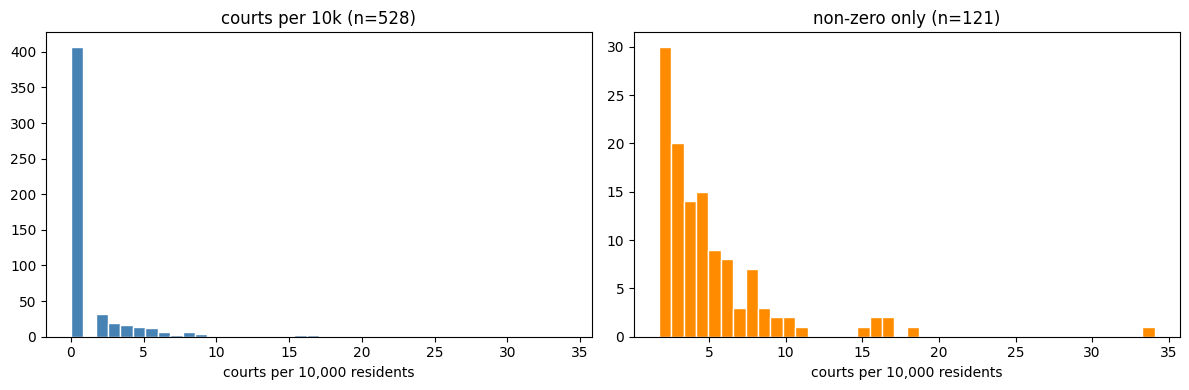

count    528.000000
mean       1.177791
std        2.982394
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max       34.090909
Name: courts_per_10k, dtype: float64

zeros: 407 of 528 (77.1%)
skew: 4.73


In [42]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

d = analysis.courts_per_10k.dropna()
axes[0].hist(d, bins=40, color='steelblue', edgecolor='white')
axes[0].set_title(f'courts per 10k (n={len(d)})')
axes[0].set_xlabel('courts per 10,000 residents')

nz = d[d > 0]
axes[1].hist(nz, bins=40, color='darkorange', edgecolor='white')
axes[1].set_title(f'non-zero only (n={len(nz)})')
axes[1].set_xlabel('courts per 10,000 residents')

plt.tight_layout(); plt.show()

print(d.describe())
print(f"\nzeros: {(d == 0).sum()} of {len(d)} ({(d == 0).mean():.1%})")
print(f"skew: {d.skew():.2f}")


# Analysis

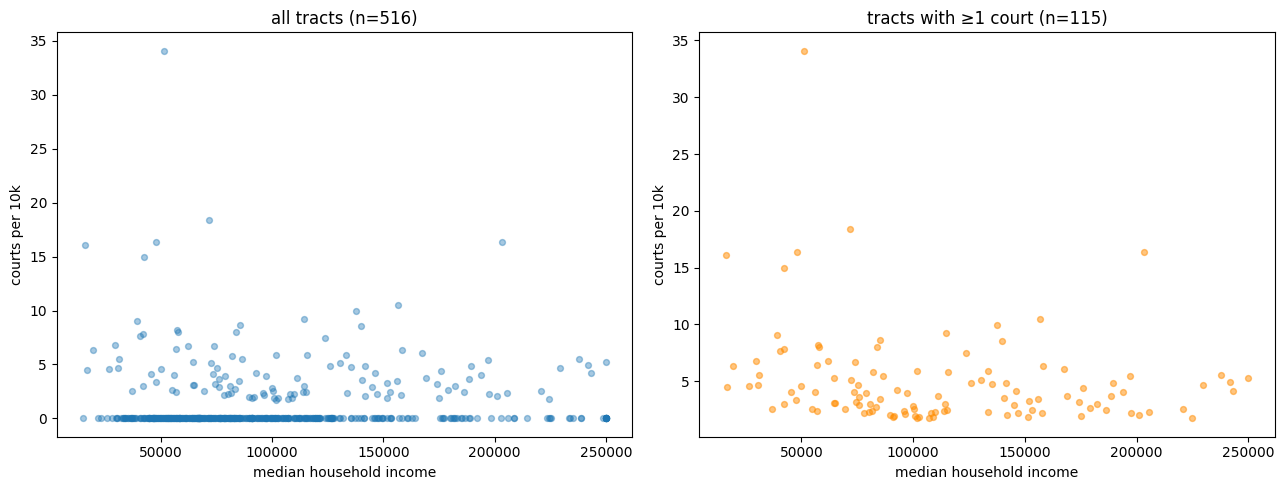

In [43]:

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

d = analysis.dropna(subset=['courts_per_10k', 'median_household_income'])

ax[0].scatter(d.median_household_income, d.courts_per_10k, alpha=0.4, s=18)
ax[0].set(xlabel='median household income', ylabel='courts per 10k',
          title=f'all tracts (n={len(d)})')

nz = d[d.courts_per_10k > 0]
ax[1].scatter(nz.median_household_income, nz.courts_per_10k, alpha=0.5, s=18, color='darkorange')
ax[1].set(xlabel='median household income', ylabel='courts per 10k',
          title=f'tracts with ≥1 court (n={len(nz)})')

plt.tight_layout(); plt.show()


In [44]:
from scipy import stats

def compare(x, y, xname, yname):
    m = analysis[[x, y]].dropna()
    if len(m) < 10:
        return
    pear = stats.pearsonr(m[x], m[y])
    spear = stats.spearmanr(m[x], m[y])
    print(f"{xname:22s} vs {yname:16s} n={len(m):3d}  "
          f"Pearson r={pear.statistic:+.3f} (p={pear.pvalue:.3f})  "
          f"Spearman ρ={spear.statistic:+.3f} (p={spear.pvalue:.3f})")

for metric in ['courts_per_10k', 'courts_per_sqmi']:
    print(f"\n--- {metric} ---")
    for col in ['median_household_income', 'OBESITY', 'LPA', 'MHLTH']:
        compare(metric, col, metric, col)



--- courts_per_10k ---
courts_per_10k         vs median_household_income n=516  Pearson r=+0.015 (p=0.726)  Spearman ρ=+0.104 (p=0.018)
courts_per_10k         vs OBESITY          n=528  Pearson r=+0.046 (p=0.287)  Spearman ρ=-0.075 (p=0.086)
courts_per_10k         vs LPA              n=528  Pearson r=+0.080 (p=0.065)  Spearman ρ=-0.030 (p=0.496)
courts_per_10k         vs MHLTH            n=528  Pearson r=+0.093 (p=0.033)  Spearman ρ=-0.048 (p=0.270)

--- courts_per_sqmi ---
courts_per_sqmi        vs median_household_income n=516  Pearson r=-0.055 (p=0.209)  Spearman ρ=+0.106 (p=0.016)
courts_per_sqmi        vs OBESITY          n=528  Pearson r=+0.075 (p=0.087)  Spearman ρ=-0.083 (p=0.058)
courts_per_sqmi        vs LPA              n=528  Pearson r=+0.111 (p=0.011)  Spearman ρ=-0.040 (p=0.358)
courts_per_sqmi        vs MHLTH            n=528  Pearson r=+0.178 (p=0.000)  Spearman ρ=-0.041 (p=0.342)


In [45]:
inc_q25 = analysis.median_household_income.quantile(0.25)
lpa_q75 = analysis.LPA.quantile(0.75)

print(f"income 25th pct: ${inc_q25:,.0f}")
print(f"LPA 75th pct:    {lpa_q75:.1f}%")

c1 = analysis.court_count == 0
print(f"\nno courts:                    {c1.sum():3d}")

c2 = c1 & (analysis.median_household_income <= inc_q25)
print(f"  + bottom-quartile income:   {c2.sum():3d}")

c3 = c2 & (analysis.LPA >= lpa_q75)
print(f"  + top-quartile inactivity:  {c3.sum():3d}")


income 25th pct: $59,781
LPA 75th pct:    27.6%

no courts:                    409
  + bottom-quartile income:   105
  + top-quartile inactivity:   82


In [46]:
deserts = analysis[c3].copy()
cols = ['NAMELSAD', 'median_household_income', 'total_population',
        'pop_black_alone', 'LPA', 'OBESITY', 'area_sqmi']
print(deserts.sort_values('median_household_income')[cols].to_string(index=False))


           NAMELSAD  median_household_income  total_population  pop_black_alone  LPA  OBESITY  area_sqmi
 Census Tract 78.08                  14971.0              3877             3617 49.6     48.7   0.629692
 Census Tract 55.03                  21686.0              1617             1592 38.4     43.2   0.220735
    Census Tract 75                  22981.0              3023             2504 40.6     43.5   1.284316
    Census Tract 26                  25938.0               986              820 36.4     41.8   0.369231
 Census Tract 82.02                  27857.0              2320             2099 41.8     43.5   2.694478
 Census Tract 66.02                  29784.0               865              799 40.5     45.0   0.244181
Census Tract 233.20                  30167.0              4330             4196 36.0     44.2   1.185644
 Census Tract 76.04                  30216.0              3573             3302 38.7     43.4   0.422292
Census Tract 233.17                  31824.0           

In [47]:
analysis['income_q'] = pd.qcut(analysis.median_household_income, 4,
                               labels=['Q1 (lowest)', 'Q2', 'Q3', 'Q4 (highest)'])

summary = analysis.groupby('income_q', observed=True).agg(
    tracts=('GEOID', 'size'),
    pct_no_court=('court_count', lambda s: (s == 0).mean() * 100),
    total_courts=('court_count', 'sum'),
    mean_per_10k=('courts_per_10k', 'mean'),
    median_per_10k=('courts_per_10k', 'median'),
)
print(summary.round(2).to_string())


              tracts  pct_no_court  total_courts  mean_per_10k  median_per_10k
income_q                                                                      
Q1 (lowest)      129         81.40            45          1.46             0.0
Q2               129         83.72            31          0.77             0.0
Q3               129         79.84            35          0.68             0.0
Q4 (highest)     129         65.89            70          1.52             0.0


In [48]:
analysis['pct_black'] = analysis.pop_black_alone / analysis.race_universe * 100
analysis['poverty_rate'] = analysis.population_in_poverty / analysis.poverty_universe * 100

for col in ['pct_black', 'poverty_rate']:
    compare('courts_per_10k', col, 'courts_per_10k', col)

analysis.groupby('income_q', observed=True).agg(
    pct_black=('pct_black', 'median'),
    pct_no_court=('court_count', lambda s: (s == 0).mean() * 100),
).round(1)


courts_per_10k         vs pct_black        n=528  Pearson r=-0.016 (p=0.713)  Spearman ρ=-0.063 (p=0.148)
courts_per_10k         vs poverty_rate     n=528  Pearson r=+0.157 (p=0.000)  Spearman ρ=-0.001 (p=0.976)


,pct_black,pct_no_court
income_q,,
Q1 (lowest),82.6,81.4
Q2,64.4,83.7
Q3,20.7,79.8
Q4 (highest),8.1,65.9


# Visualization

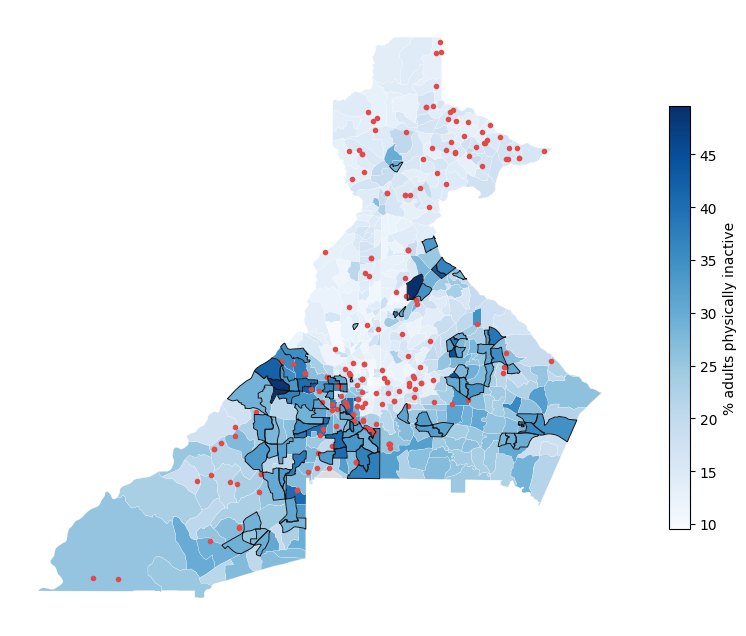

In [49]:
fig, ax = plt.subplots(figsize=(10, 10))
analysis.plot(ax=ax, column='LPA', cmap='Blues', legend=True,
              edgecolor='white', linewidth=0.15,
              missing_kwds={'color': '#dddddd'},
              legend_kwds={'shrink': 0.55, 'label': '% adults physically inactive'})

# Outline the 82 mask tracts — no fill, so the LPA color stays visible.
analysis[c3].boundary.plot(ax=ax, color='#111111', linewidth=0.7)
courts.plot(ax=ax, color='#e34948', markersize=9)
ax.set_axis_off()


In [51]:
import matplotlib.patheffects as pe
named = {'13121007808': 'Neighborhood name here'}   # verify each one
for geoid, label in named.items():
    row = analysis[analysis.GEOID == geoid]
    pt = row.geometry.centroid.iloc[0]
    ax.annotate(label, (pt.x, pt.y), fontsize=9, fontweight='bold',
                ha='center', color='#111111',
                path_effects=[pe.withStroke(linewidth=2.5, foreground='white')])


/var/folders/cm/46nnvpl978b_vb10b1dp7rp80000gn/T/ipykernel_40794/3337600612.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  pt = row.geometry.centroid.iloc[0]
